Ce fichier enregistre dans un fichier excel les résultats de la méthode de détection grâce à la power window de Mindmaze : SOMME((ACx*GYROx) + (ACy*GYROy) +(ACz*GYROz)) sur des fenetre de 10 sec. Si la somme est sup à une valeur alors il y a un mvt. Or cette valeur n'est pas spécifié : on essaie de la trouver en collant à nos données.
Les résultats étant différents, le fichier à été modifié pour affiché les valeurs des annotations selon 3 définition du mouvement : GA (un mouvement correspond uniquement aux annotaions Grande Amplitude volontaire), FAGA (un mouvement correspond aux annotations Grande Amplitude et Faible Amplitude volontaires) et all (un mouvement correspond aux annotations Grande amplitude et Faible Amplitude, volontaires et involontaires).

Pour le lancer et obtenir les données d'un fichier il faut changer 4 paramètres :
- les indices de folder dans la boucle for principale (1. Récupération des AC et des annotations)
- les indices de folder dans la boucle for principale (3. b. Récupération des données gyroscopiques)
- le nom de file_path_dom (4. a. Enregistrement dans excel pour membre dominant)
- le nom de file path_non_dom (4. b. Enregistrement dans excel pour membre non dominant)

In [403]:
import os
import struct
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score
from agcounts_filter import convert_AC
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from scipy.signal import medfilt, resample_poly
from scipy.ndimage import maximum_filter1d

1. Récupération des accélération sur 3 axes et des annotations

In [404]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

#////////////////////////////// Attention : le fichier LW est défini comme le dominant ////////////////////////////////

# Initialisation des listes contenant les données des capteurs
X_non_dom = []
X_dom = []
idx_X_non_dom = 0
idx_X_dom = 0
idx_Y_dom = 0
idx_Y_non_dom = 0

# Annotations all
Y_dom_all = []
Y_non_dom_all = []
# Annotations FAGA
Y_dom_faga = []
Y_non_dom_faga = []
# Annotations GA
Y_dom_ga = []
Y_non_dom_ga = []

# Initialisation des listes contenant les annotations vidéos
Y_non_dom = [] 
Y_dom = []

#Parcourir les fichiers CSV
for file in folder[25:28]: # //////////////////////// Ajuster les indices pour choisir le fichier à analyser
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    # Pour les cas ou il y a des annotations avant le start
    allow_start_dom = None
    allow_start_non_dom = None

    """********************************************************************** 1. Lecture des fichiers csv ******************************************************************************"""
    if extension == ".csv":
        # Récupération des noms des colonnes pour pouvoir lire le fichier (pas le m^me pour tous)
        csv_file_column = pd.read_csv(folder_path + "/" + file, skiprows=5, sep = ',', low_memory = False)
        lst_column = list(csv_file_column)

        # Les fichiers n'ont pas tous le même nombre de données
        if lst_column == ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"]:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Event","Quat W","Quat X","Quat Y","Quat Z","Unnamed: 12"], dtype = {"Event":str},low_memory=False)
        elif lst_column == ['Time', 'Gyro X', 'Gyro Y', 'Gyro Z', 'Accel X', 'Accel Y', 'Accel Z', 'Quat W', 'Quat X', 'Quat Y', 'Quat Z', 'Unnamed: 11']:
            data_file = pd.read_csv(folder_path + "/" + file, skiprows=7,decimal=",", names = ["Time","Gyro X","Gyro Y","Gyro Z","Accel X","Accel Y","Accel Z","Quat W","Quat X","Quat Y","Quat Z"],low_memory=False) #names=list(dtype_dict.keys()), dtype=dtype_dict)

        # Conversion en AC 
        dom_AC = convert_AC(folder_path + "/" + file)

        # Enregistrement des données des capteurs dans les listes qui seront donnnées au classificateur
        if file[-11:-4] == "non_dom":
            list_dom_x = dom_AC["Axis1"].tolist()
            list_dom_y = dom_AC["Axis2"].tolist()
            list_dom_z = dom_AC["Axis3"].tolist()
            #list_dom_AC = dom_AC["AC"].tolist()
            #for ac in list_dom_AC :
                #X_non_dom.append()

        elif file[-7:-4] == "dom":
            list_non_dom_x = dom_AC["Axis1"].tolist()
            list_non_dom_y = dom_AC["Axis2"].tolist()
            list_non_dom_z = dom_AC["Axis3"].tolist()
            #list_dom_AC = dom_AC["AC"].tolist()
            #for ac in list_dom_AC:
                #X_dom.append(ac)

        

    """********************************************************** 2. Enregistrer les annotations ***************************************************************************"""

    if extension == ".xlsx":

        my_wb = openpyxl.load_workbook(folder_path + "/" + file) 
        my_sheet = my_wb.active

        # Initialisation des décalages : sert pour éviter le décalage du aux arrondis des annotations 
        decalage_dom = 0
        decalage_non_dom = 0

        for label in my_sheet["H"]: 

            """*********************************************** Récupération du début de Y ****************************************************"""
            # dom
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_LW" :
                start_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                """# Décalage pour synchroniser X et Y
                for decalage in range(start_dom):
                    Y_dom.append(None)"""
                previous_row_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_dom = True

            # non_dom 
            # Synchronisation des données X des capteurs et des annotations Y
            if label.value == "Start_RW" :
                start_non_dom = int(round(float(my_sheet.cell(label.row,13).value))) - 1
                """# Décalage pour synchroniser X et Y
                for decalage in range(start_non_dom):
                    Y_non_dom.append(None)"""
                previous_row_non_dom = label.row
                # Pour les cas ou il y a des annotations avant le start 
                allow_start_non_dom = True

            """****************************************************** Récupération du contenu de Y ****************************************"""

            if label.value[0:2] == "LW" and allow_start_dom:

                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_dom , 13).value)) 
                    for diff in range(0, difference):
                        Y_dom.append(None) 
                    
                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value))) 
                for nb_sec in range(nb_repetitions): 
                    # GA
                    if label.value[-5:] == " V GA":
                        Y_dom_ga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                        Y_dom_ga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom_ga.append(None)

                    # FAGA
                    if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                        Y_dom_faga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                        Y_dom_faga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom_faga.append(None)


                    # all
                    if X_dom and (len(Y_dom) == len(X_dom)) :
                        break
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA": # GA : # if label.value[-5:] == " V GA": # FAGA : # if label.value[-5:] == " V GA" or label.value[-5:] == " V FA": # ALL : # if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_dom.append("mouvement")
                        Y_dom_all.append("mouvement")
                    elif label.value[3:13] == "sédentaire": # GA : # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA": # FAGA # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA": # ALL : #  elif label.value[3:13] == "sédentaire":
                        Y_dom.append("non mouvement")
                        Y_dom_all.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_dom.append(None) 
                        Y_dom_all.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_dom = label.row


            elif label.value[0:2] == "RW" and allow_start_non_dom:
                
                # Récupération de l'index de la ligne
                row = label.row

                # Synchronisation si le start de l'annotation ne correspond pas au stop de l'annotation précédentes
                if my_sheet.cell(row, 12).value != my_sheet.cell(previous_row_non_dom, 13).value:
                    difference = round(float(my_sheet.cell(row, 12).value)) - round(float(my_sheet.cell(previous_row_non_dom , 13).value)) 
                    for diff in range(0,difference):
                        Y_non_dom.append(None)

                # Synchronisation des données des capteurs avec les annotations
                nb_repetitions = int(round(float(my_sheet.cell(label.row, 13).value))) - int(round(float(my_sheet.cell(label.row, 12).value)))
                for nb_sec in range(nb_repetitions): 
                    if X_non_dom and (len(Y_non_dom) == len(X_non_dom)): 
                        break
                    # GA 
                    if label.value[-5:] == " V GA":
                        Y_non_dom_ga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA":
                        Y_non_dom_ga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom_ga.append(None)
                    # FAGA
                    if label.value[-5:] == " V GA" or label.value[-5:] == " V FA":
                        Y_non_dom_faga.append("mouvement")
                    elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA":
                        Y_non_dom_faga.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom_faga.append(None)

                    # all    
                    if label.value[-2:] == "GA" or label.value[-2:] == "FA": # GA : # if label.value[-5:] == " V GA": # FAGA : # if label.value[-5:] == " V GA" or label.value[-5:] == " V FA": # ALL : # if label.value[-2:] == "GA" or label.value[-2:] == "FA":
                        Y_non_dom.append("mouvement")
                        Y_non_dom_all.append("mouvement")
                    elif label.value[3:13] == "sédentaire": # GA : # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-2:] == "FA": # FAGA # elif label.value[3:13] == "sédentaire" or label.value[-5:] == "IV GA" or label.value[-5:] == "IV FA": # ALL : #  elif label.value[3:13] == "sédentaire"
                        Y_non_dom.append("non mouvement")
                        Y_non_dom_all.append("non mouvement")
                    elif label.value[3:12] == "non noté":
                        Y_non_dom.append(None)
                        Y_non_dom_all.append(None)

                #Au prochain tour, l'indice de la ligne actuelle sera l'index de la ligne précédente
                previous_row_non_dom = label.row

        # CROPER X A LA LONGUEUR DE Y 
        list_dom_x = list_dom_x[:len(Y_dom)] 
        list_dom_y = list_dom_y[:len(Y_dom)] 
        list_dom_z = list_dom_z[:len(Y_dom)] 
        list_non_dom_x = list_non_dom_x[:len(Y_non_dom)]
        list_non_dom_y = list_non_dom_y[:len(Y_non_dom)]
        list_non_dom_z = list_non_dom_z[:len(Y_non_dom)]
        Y_dom = Y_dom[:len(list_dom_x) ]
        Y_non_dom = Y_non_dom[:len(list_non_dom_x) ]

        # cROPER LES ANNOTATIONS
        Y_dom_all = Y_dom_all[:len(list_dom_x)]
        Y_non_dom_all = Y_non_dom_all[:len(list_non_dom_x)]
        Y_dom_faga = Y_dom_faga[:len(list_dom_x)]
        Y_non_dom_faga = Y_non_dom_faga[:len(list_non_dom_x)]
        Y_dom_ga = Y_dom_ga[:len(list_dom_x)]
        Y_non_dom_ga = Y_non_dom_ga[:len(list_non_dom_x)]

Y_dom = np.array(Y_dom)
Y_non_dom = np.array(Y_non_dom)
list_dom_x = np.array(list_dom_x)
list_dom_y = np.array(list_dom_y)
list_dom_z = np.array(list_dom_z)
list_non_dom_x = np.array(list_non_dom_x)
list_non_dom_y = np.array(list_non_dom_y)
list_non_dom_z = np.array(list_non_dom_z)

On est dans le fichier : Data_8_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_8_non_dom.csv
Reading in CSV
Converting to array
Getting Counts
On est dans le fichier : Data_8_X.xlsx


Affichage des données

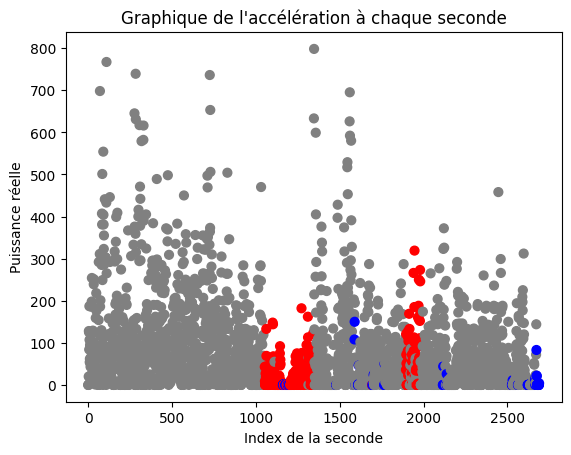

len(Y_non_dom) avant nettoyage : 2566


In [405]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(list_non_dom_x)), list_non_dom_x, c=colors, s=40)
plt.title("Graphique de l'accélération à chaque seconde")
plt.xlabel("Index de la seconde")
plt.ylabel("Puissance réelle")
plt.show()

print("len(Y_non_dom) avant nettoyage :", len(Y_dom))

2. Récupération des données gyroscopiques

In [406]:
folder_path = "C:/Users/roman/Documents/BEaCHILD/X_et_Y" 
folder = os.listdir(folder_path)

# Initialisation des listes contenant les données des capteurs
X_gyro_dom = []
Y_gyro_dom = []
Z_gyro_dom = []
X_gyro_non_dom = []
Y_gyro_non_dom = []
Z_gyro_non_dom = []

for file in folder[25:28]: # /////////////////////////////////////////////// Modifier le fichier
    print(f"On est dans le fichier : {file}")

    # Extension du fichier
    extension = os.path.splitext(file)[1] 

    if extension == ".csv":
        # Récupération des données des capteurs
        data_file = pd.read_csv(folder_path + "/" + file, header = 5, names = ["Timestamp","Gyro X","Gyro Y","Gyro Z","Accelerometer X","Accelerometer Y","Accelerometer Z","Event","Quat W","Quat X","Quat Y","Quat Z","None"])    
        
        if file[-11:-4] == "non_dom":
            X_gyro_non_dom.extend(data_file["Gyro X"].values.tolist()) 
            Y_gyro_non_dom.extend(data_file["Gyro Y"].values.tolist()) 
            Z_gyro_non_dom.extend(data_file["Gyro Z"].values.tolist())
        
        elif file[-7:-4] == "dom":
            X_gyro_dom.extend(data_file["Gyro X"].values.tolist()) 
            Y_gyro_dom.extend(data_file["Gyro Y"].values.tolist()) 
            Z_gyro_dom.extend(data_file["Gyro Z"].values.tolist())

print(len(X_gyro_dom))

On est dans le fichier : Data_8_dom.csv
On est dans le fichier : Data_8_non_dom.csv
On est dans le fichier : Data_8_X.xlsx
498939


3. Calcul de la power window pour chaque fenetre de 10 sec

In [407]:
time_window = 10 # fenetre de 2 secondes
lst_power_window_dom = []
lst_power_window_non_dom = []

print(len(list_dom_x))
for idx_window in range(0,min(len(list_dom_x)//time_window*time_window,len(list_non_dom_x)//time_window*time_window), time_window):
    
    # Récuépration des x sur la fenetre
    acc_x_dom = np.mean(list_dom_x[idx_window : idx_window + time_window])
    acc_x_non_dom = np.mean(list_non_dom_x[idx_window : idx_window + time_window])
    gyro_x_dom = np.mean(X_gyro_dom[idx_window : idx_window + time_window])
    gyro_x_non_dom = np.mean(X_gyro_non_dom[idx_window : idx_window + time_window])
    # Récuépration des y sur la fenetre
    acc_y_dom = np.mean(list_dom_y[idx_window : idx_window + time_window])
    acc_y_non_dom = np.mean(list_non_dom_y[idx_window : idx_window + time_window])
    gyro_y_dom = np.mean(Y_gyro_dom[idx_window : idx_window + time_window])
    gyro_y_non_dom = np.mean(Y_gyro_non_dom[idx_window : idx_window + time_window])
    # Récuépration des z sur la fenetre
    acc_z_dom = np.mean(list_dom_z[idx_window : idx_window + time_window])
    acc_z_non_dom = np.mean(list_non_dom_z[idx_window : idx_window + time_window])
    gyro_z_dom = np.mean(Z_gyro_dom[idx_window : idx_window + time_window])
    gyro_z_non_dom = np.mean(Z_gyro_non_dom[idx_window : idx_window + time_window])

    # Power windom 
    power_window_dom = acc_x_dom * gyro_x_dom + acc_y_dom * gyro_y_dom + acc_z_dom * gyro_z_dom
    power_window_non_dom = acc_x_non_dom * gyro_x_non_dom + acc_y_non_dom * gyro_y_non_dom + acc_z_non_dom * gyro_z_non_dom

    for i in range(time_window):
        lst_power_window_dom.append(power_window_dom)
        lst_power_window_non_dom.append(power_window_non_dom)

print(len(lst_power_window_dom))
print(lst_power_window_dom)


2566
2560
[193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 193.03176890000003, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 40.26692969999999, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 91.69807, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 0.8732115000000025, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 96.880587, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721100000006, 59.089721

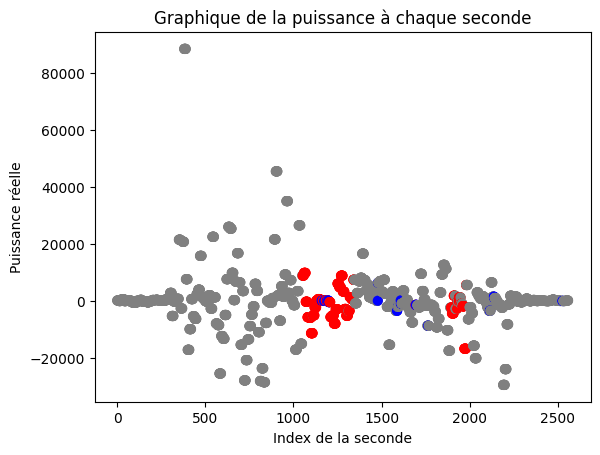

len(Y_non_dom) avant nettoyage : 2566


In [408]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom[:len(lst_power_window_non_dom)]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_non_dom)), lst_power_window_non_dom, c=colors, s=40)
plt.title("Graphique de la puissance à chaque seconde")
plt.xlabel("Index de la seconde")
plt.ylabel("Puissance réelle")
plt.show()

print("len(Y_non_dom) avant nettoyage :", len(Y_dom))

4.a. Nettoyage des AC et de leur annotations

In [409]:
total_list_dom_sec = np.arange(1,len(Y_dom)+1)
total_list_non_dom_sec = np.arange(1,len(Y_non_dom)+1)
lst_power_window_dom = np.array(lst_power_window_dom)
lst_power_window_non_dom = np.array(lst_power_window_non_dom)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_dom = Y_dom != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_non_dom = Y_non_dom != None

lst_power_window_dom = lst_power_window_dom[mask_dom[0:len(lst_power_window_dom)]]
print(len(lst_power_window_non_dom))
print(len(Y_non_dom))
lst_power_window_non_dom = lst_power_window_non_dom[mask_non_dom[0:len(lst_power_window_non_dom)]]
Y_dom = Y_dom[mask_dom]
Y_non_dom = Y_non_dom[mask_non_dom]
list_dom_sec =  total_list_dom_sec[mask_dom]
list_non_dom_sec = total_list_non_dom_sec[mask_non_dom]

print("len(Y_non_dom) après nettoyage :", len(Y_non_dom))

2560
2690
len(Y_non_dom) après nettoyage : 425


4. b. Nettoyage des annotations GA, FAGA et all

In [410]:
Y_dom_all = np.array(Y_dom_all)
Y_non_dom_all = np.array(Y_non_dom_all)
Y_dom_faga = np.array(Y_dom_faga)
Y_non_dom_faga = np.array(Y_non_dom_faga)
Y_dom_ga = np.array(Y_dom_ga)
Y_non_dom_ga = np.array(Y_non_dom_ga)

# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_all_dom = Y_dom_all != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_all_non_dom = Y_non_dom_all != None

Y_dom_all = Y_dom_all[mask_all_dom]
Y_non_dom_all = Y_non_dom_all[mask_all_non_dom]


# GA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_dom = Y_dom_ga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_ga_non_dom = Y_non_dom_ga != None

Y_dom_ga = Y_dom_ga[mask_ga_dom]
Y_non_dom_ga = Y_non_dom_ga[mask_ga_non_dom]

#FAGA
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_dom = Y_dom_faga != None
# Créer un masque pour garder uniquement les étiquettes valides (différent de None)
mask_faga_non_dom = Y_non_dom_faga != None

Y_dom_faga = Y_dom_faga[mask_faga_dom]
Y_non_dom_faga = Y_non_dom_faga[mask_faga_non_dom]


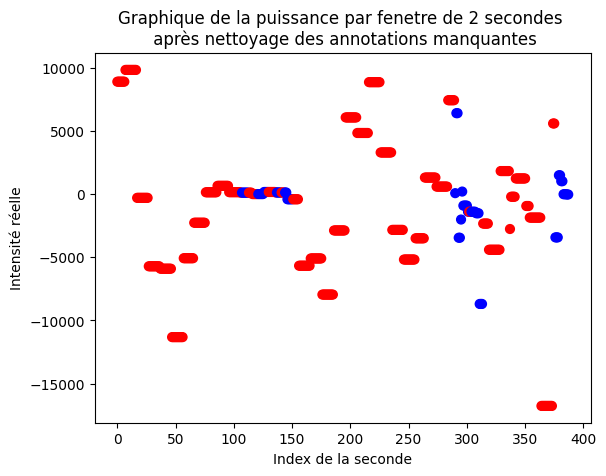

In [411]:
# Crée un mapping de couleur pour chaque label
label_to_color = {'mouvement': 'red', 'non mouvement': 'blue', None : 'grey'}
colors = [label_to_color[y] for y in Y_non_dom_all[:len(lst_power_window_non_dom)]]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_non_dom)), lst_power_window_non_dom, c=colors, s=40)
plt.title("Graphique de la puissance par fenetre de 2 secondes \n après nettoyage des annotations manquantes")
plt.xlabel("Index de la seconde")
plt.ylabel("Intensité réelle")
plt.show()



5. Prédiction du seuil

In [412]:
window_pred_dom = []
window_pred_non_dom = []

# Prediction for dominant member
for value in lst_power_window_dom:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_dom.append(1)
    else: #elif value == 0:
        window_pred_dom.append(0)

# Prediction for non dominant member
for value in lst_power_window_non_dom:
    if value > 1 or value < -1 : #if value > 1 or value < -1:
        window_pred_non_dom.append(1)
    else: #elif value <= 0:
        window_pred_non_dom.append(0)

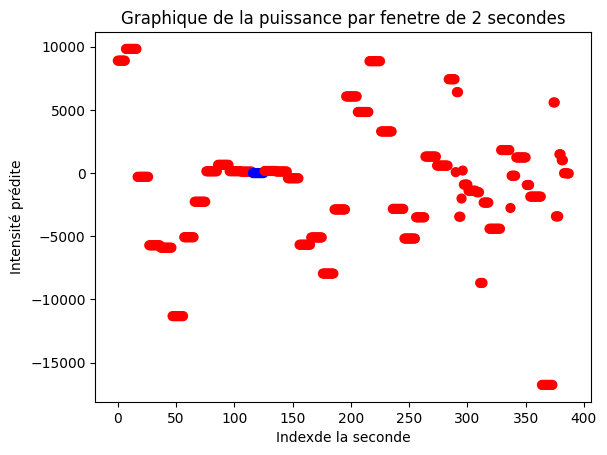

len(lst_power_window_dom) après nettoyage : 388


In [413]:
# Crée un mapping de couleur pour chaque label
label_to_color = {1: 'red', 0: 'blue', None : 'grey'}
colors = [label_to_color[y] for y in window_pred_non_dom]
# Affichage : index en abscisse, intensité en ordonnée
plt.scatter(range(len(lst_power_window_non_dom)), lst_power_window_non_dom, c=colors, s=40)
plt.title("Graphique de la puissance par fenetre de 2 secondes")
plt.xlabel("Indexde la seconde")
plt.ylabel("Intensité prédite")
plt.show()

print("len(lst_power_window_dom) après nettoyage :", len(lst_power_window_non_dom))


6. a. Enregistrement dans excel pour membre dominant

In [414]:
"""file_path_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification/Comparaison_mindmaze/Puissance_dimension6/Sans_fenetre/Puissance_dom_02.08.02_MS_01.xlsx"
# Select file
if os.path.exists(file_path_dom):
    my_wb = openpyxl.load_workbook(file_path_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Detection de puissance", "Prediction (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pas_pred in range(len(lst_power_window_dom)):
    my_cell = my_sheet.cell(row = idx_pas_pred + 2, column = 2)
    my_cell.value = lst_power_window_dom[idx_pas_pred]

# 3e colonne = prédiction fenetre de puissance> 0
for idx_pred_0 in range(len(window_pred_dom)):
    my_cell = my_sheet.cell(row = idx_pred_0 + 2, column = 3)
    my_cell.value = int(window_pred_dom[idx_pred_0])

# 4e colonne = Observation GA
for idx_obs_ga in range(len(Y_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 4)
    if Y_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 5e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 5)
    if Y_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 6e colonne = Observation All
for idx_obs_all in range(len(Y_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 6)
    if Y_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"

my_wb.save(file_path_dom)"""

'file_path_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification/Comparaison_mindmaze/Puissance_dimension6/Sans_fenetre/Puissance_dom_02.08.02_MS_01.xlsx"\n# Select file\nif os.path.exists(file_path_dom):\n    my_wb = openpyxl.load_workbook(file_path_dom)  \n    print("File exists, loading existing data.")\nelse:\n    # Create file \n    my_wb = openpyxl.Workbook()\n    print("File does not exist, creating a new file.")\n\n# Nomenclature des colonnes\nmy_sheet = my_wb.active\n\n\n\nnames_column = ["Timecode (sec)", "Detection de puissance", "Prediction (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]\nfor name_nb in range(0,len(names_column)) :\n    print("créer une colonne")\n    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)\n    my_cell.value = names_column[name_nb]\n\n\n# 1ere colonne = seconde\nfor idx_sec in range(len(list_dom_sec)):\n

6. b. Enregistrement dans excel pour membre non dominant

In [415]:
"""file_path_non_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification/Comparaison_mindmaze/Puissance_dimension6/Sans_fenetre/Puissance_non_dom_02.08.02_MS_01.xlsx"
# Select file
if os.path.exists(file_path_non_dom):
    my_wb = openpyxl.load_workbook(file_path_non_dom)  
    print("File exists, loading existing data.")
else:
    # Create file 
    my_wb = openpyxl.Workbook()
    print("File does not exist, creating a new file.")

# Nomenclature des colonnes
my_sheet = my_wb.active



names_column = ["Timecode (sec)", "Detection de puissance", "Prédiction (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]
for name_nb in range(0,len(names_column)) :
    print("créer une colonne")
    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)
    my_cell.value = names_column[name_nb]


# 1ere colonne = seconde
for idx_sec in range(len(list_non_dom_sec)):
    my_cell = my_sheet.cell(row = idx_sec + 2, column = 1)
    my_cell.value = list_non_dom_sec[idx_sec]

# 2e colonne = résultats fenetre de puissance
for idx_pas_pred in range(len(lst_power_window_non_dom)):
    my_cell = my_sheet.cell(row = idx_pas_pred + 2, column = 2)
    my_cell.value = lst_power_window_non_dom[idx_pas_pred]

# 3e colonne = prédiction résultats fenetre de puissance > 0
for idx_pred_0 in range(len(window_pred_non_dom)):
    my_cell = my_sheet.cell(row = idx_pred_0 + 2, column = 3)
    my_cell.value = int(window_pred_non_dom[idx_pred_0])

# 4e colonne = Observation GA
for idx_obs_ga in range(len(Y_non_dom_ga)):
    my_cell = my_sheet.cell(row = idx_obs_ga + 2, column = 4)
    if Y_non_dom_ga[idx_obs_ga] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_ga[idx_obs_ga] == "non mouvement":
        my_cell.value = 0
    else:
        my_cell.value = None

# 5e colonne = Observation GAFA
for idx_obs_gafa in range(len(Y_non_dom_faga)):
    my_cell = my_sheet.cell(row = idx_obs_gafa + 2, column = 5)
    if Y_non_dom_faga[idx_obs_gafa] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_faga[idx_obs_gafa] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_faga[idx_obs_gafa])
        my_cell.value = "ERREUR"

# 6e colonne = Observation All
for idx_obs_all in range(len(Y_non_dom_all)):
    my_cell = my_sheet.cell(row = idx_obs_all + 2, column = 6)
    if Y_non_dom_all[idx_obs_all] == "mouvement":
        my_cell.value = 1
    elif Y_non_dom_all[idx_obs_all] == "non mouvement":
        my_cell.value = 0
    else:
        #print(Y_non_dom_all[idx_obs_all])
        my_cell.value = "ERREUR"

my_wb.save(file_path_non_dom)"""

'file_path_non_dom = "C:/Users/roman/Documents/BEaCHILD/Classification/Classification/Comparaison_mindmaze/Puissance_dimension6/Sans_fenetre/Puissance_non_dom_02.08.02_MS_01.xlsx"\n# Select file\nif os.path.exists(file_path_non_dom):\n    my_wb = openpyxl.load_workbook(file_path_non_dom)  \n    print("File exists, loading existing data.")\nelse:\n    # Create file \n    my_wb = openpyxl.Workbook()\n    print("File does not exist, creating a new file.")\n\n# Nomenclature des colonnes\nmy_sheet = my_wb.active\n\n\n\nnames_column = ["Timecode (sec)", "Detection de puissance", "Prédiction (0 no movement, 1 movement)", "GA observation (0 no movement, 1 movement)", "GAFA Observation (0 no movement, 1 movement)", "all observation (0 no movement, 1 movement)"]\nfor name_nb in range(0,len(names_column)) :\n    print("créer une colonne")\n    my_cell = my_sheet.cell(row = 1, column = name_nb + 1)\n    my_cell.value = names_column[name_nb]\n\n\n# 1ere colonne = seconde\nfor idx_sec in range(len(l